# Q3: Feature Engineering and Regression Pipeline

**Objective:** Build a reproducible scikit-learn regression pipeline to predict `items_sold` at a retail store.

**Dataset columns:** `transaction_date`, `store_id`, `store_size`, `location_type`, `promotion_type`, `is_weekend`, `is_festival`, `competition_density`, `items_sold`

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42

---
## Task 1 — Date Feature Engineering

Raw dates are not directly usable by ML models. We extract meaningful temporal signals from `transaction_date`:
- **`year`** — captures long-term growth trends
- **`month`** — captures seasonal demand (e.g., holiday spikes)
- **`day_of_week`** — captures weekly purchase patterns (Mon=0, Sun=6)
- **`is_month_end`** — binary flag for the last week of the month (day >= 25); salary periods often drive higher retail spend

In [2]:
# Load dataset
df = pd.read_csv('../data/q3_retail_promotions.csv')

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape: 1200 rows x 9 columns

Data types:
transaction_date         str
store_id               int64
store_size               str
location_type            str
promotion_type           str
is_weekend             int64
is_festival            int64
competition_density    int64
items_sold             int64
dtype: object

Missing values:
transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
dtype: int64


In [3]:
# Parse transaction_date as datetime — essential before any date extraction
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# ── Extract temporal features ─────────────────────────────────────────────────
df['year']        = df['transaction_date'].dt.year
df['month']       = df['transaction_date'].dt.month          # 1-12
df['day_of_week'] = df['transaction_date'].dt.dayofweek      # 0=Monday, 6=Sunday

# is_month_end: 1 if day of month is >= 25, else 0
# Rationale: the final week of the month aligns with salary cycles and
# end-of-month promotions that typically boost retail sales.
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("New features added: year, month, day_of_week, is_month_end")
print(f"\nSample of engineered dataframe:")
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end', 'items_sold']].head(10)

New features added: year, month, day_of_week, is_month_end

Sample of engineered dataframe:


,transaction_date,year,month,day_of_week,is_month_end,items_sold
0,2022-01-01,2022,1,5,0,224
1,2022-01-01,2022,1,5,0,348
2,2022-01-02,2022,1,6,0,249
3,2022-01-02,2022,1,6,0,259
4,2022-01-03,2022,1,0,0,277
5,2022-01-03,2022,1,0,0,411
6,2022-01-04,2022,1,1,0,193
7,2022-01-04,2022,1,1,0,240
8,2022-01-05,2022,1,2,0,305
9,2022-01-05,2022,1,2,0,181


---
## Task 2 — Temporal Train-Test Split

### Why random splitting is inappropriate for time-series data

A **random split** shuffles records irrespective of time order. This means the training set could contain data from **after** the test set, effectively allowing the model to learn from the future. This is a form of **data leakage** that produces artificially optimistic evaluation metrics. The model would appear to generalise well, but would fail in real deployment where future data is unavailable at prediction time.

A **temporal split** — where the test set is strictly the most recent 20% of records — reflects the true production scenario: we always train on past data and predict on future unseen data. This gives an honest estimate of how the model will perform over time.

In [4]:
# Sort by date to enforce temporal ordering
df.sort_values('transaction_date', inplace=True)
df.reset_index(drop=True, inplace=True)

# ── Temporal 80/20 split ──────────────────────────────────────────────────────
split_idx = int(len(df) * 0.80)

train_df = df.iloc[:split_idx].copy()   # earliest 80%
test_df  = df.iloc[split_idx:].copy()   # most recent 20%

print(f"Training set : {len(train_df):,} records"
      f" ({train_df['transaction_date'].min().date()} to {train_df['transaction_date'].max().date()})")
print(f"Test set     : {len(test_df):,} records"
      f" ({test_df['transaction_date'].min().date()} to {test_df['transaction_date'].max().date()})")
print("\nTest set is strictly more recent than the training set — no leakage.")

Training set : 960 records (2022-01-01 to 2024-06-11)
Test set     : 240 records (2024-06-12 to 2024-12-31)

Test set is strictly more recent than the training set — no leakage.


---
## Task 3 — Preprocessing Pipeline

We build a `scikit-learn` `Pipeline` with a `ColumnTransformer` so that:
- **All preprocessing steps are encapsulated** — no manual transformations after the split.
- **The pipeline is fit only on training data** — `scaler.mean_` and OHE categories are learned from train, then applied identically to test. This is critical to prevent data leakage.
- **Reproducibility** — wrapping everything in a single Pipeline object means the same transformation can be applied to any new data in production.

In [5]:
# ── Define feature groups ─────────────────────────────────────────────────────
# Categorical features -> One-Hot Encoding
cat_features = ['promotion_type', 'location_type', 'store_size']

# Numerical features -> StandardScaler
# Includes original numerics + engineered date features + binary flags
num_features = [
    'competition_density', 'is_weekend', 'is_festival',
    'year', 'month', 'day_of_week', 'is_month_end'
]

# Drop columns not used as model features
drop_cols = ['transaction_date', 'store_id', 'items_sold']
TARGET = 'items_sold'

# ── Separate X and y ─────────────────────────────────────────────────────────
X_train = train_df.drop(columns=drop_cols)
y_train = train_df[TARGET]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[TARGET]

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"\nFeature columns: {list(X_train.columns)}")

X_train shape: (960, 10)
X_test  shape: (240, 10)

Feature columns: ['store_size', 'location_type', 'promotion_type', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


In [6]:
# ── ColumnTransformer: applies different transformers to different column groups
preprocessor = ColumnTransformer(
    transformers=[
        # OHE for categoricals: handle_unknown='ignore' prevents errors on
        # unseen categories in test that were not in train
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features),

        # StandardScaler for numerics: zero mean, unit variance
        ('num', StandardScaler(), num_features)
    ],
    remainder='drop'   # drop any columns not explicitly listed
)

print("Preprocessor (ColumnTransformer) defined.")
print("  Categorical : OneHotEncoder (drop='first')")
print("  Numerical   : StandardScaler")

Preprocessor (ColumnTransformer) defined.
  Categorical : OneHotEncoder (drop='first')
  Numerical   : StandardScaler


---
## Task 4 — Model Training and Evaluation

Two models are wrapped inside full `Pipeline` objects (preprocessor + estimator):
- **Linear Regression** — fast, interpretable baseline; assumes linear relationships between features and target.
- **Random Forest Regressor** — ensemble of decision trees; captures non-linear interactions and is generally more accurate on real-world retail data.

In [7]:
# ── Build full pipelines: preprocessor + model ────────────────────────────────
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=10,          # limit depth to avoid overfitting
        random_state=RANDOM_STATE,
        n_jobs=-1              # use all CPU cores
    ))
])

# ── Fit both pipelines on the training set ONLY ───────────────────────────────
# .fit() learns preprocessing stats (mean, std, OHE categories) from X_train
pipe_lr.fit(X_train, y_train)
print("Linear Regression pipeline trained.")

pipe_rf.fit(X_train, y_train)
print("Random Forest pipeline trained.")

Linear Regression pipeline trained.
Random Forest pipeline trained.


In [8]:
# ── Generate predictions on the held-out test set ─────────────────────────────
y_pred_lr = pipe_lr.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)

# ── Compute RMSE and MAE ───────────────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{'─'*45}")
    print(f" {name}")
    print(f"{'─'*45}")
    print(f"  RMSE : {rmse:,.4f}")
    print(f"  MAE  : {mae:,.4f}")
    print()
    return rmse, mae

rmse_lr, mae_lr = evaluate('Linear Regression',       y_test, y_pred_lr)
rmse_rf, mae_rf = evaluate('Random Forest Regressor', y_test, y_pred_rf)

─────────────────────────────────────────────
 Linear Regression
─────────────────────────────────────────────
  RMSE : 27.1252
  MAE  : 21.0715

─────────────────────────────────────────────
 Random Forest Regressor
─────────────────────────────────────────────
  RMSE : 31.7041
  MAE  : 25.3537



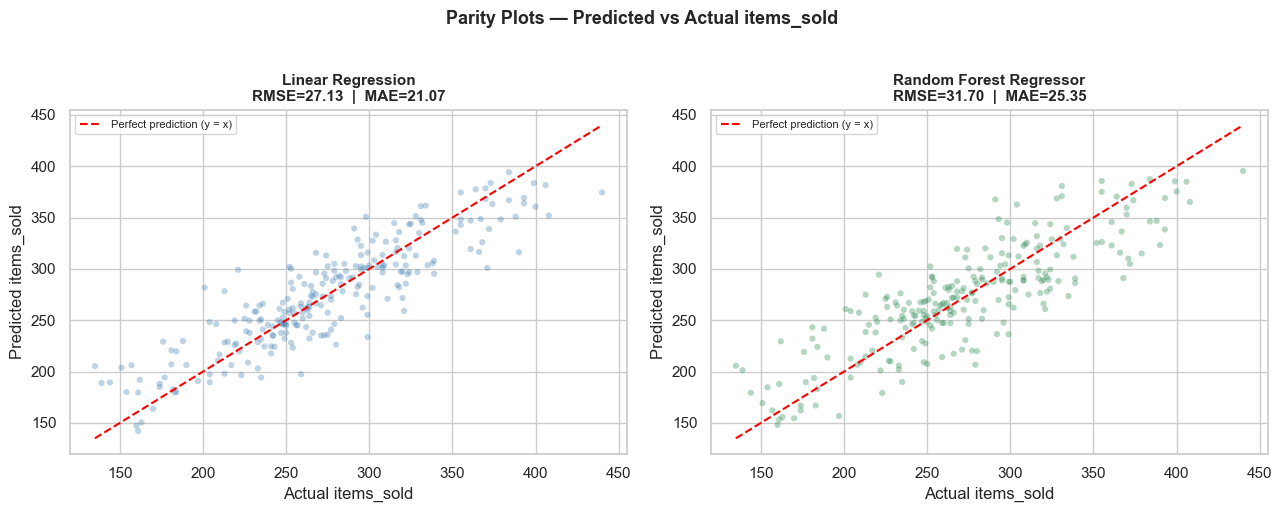

In [9]:
# ── Parity Plots: Predicted vs Actual ─────────────────────────────────────────
# A perfect model would have all points on the diagonal y=x line.
# Scatter around the diagonal reveals systematic under/over-prediction.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_configs = [
    ('Linear Regression',       y_pred_lr, rmse_lr, mae_lr,  axes[0], 'steelblue'),
    ('Random Forest Regressor', y_pred_rf, rmse_rf, mae_rf,  axes[1], 'seagreen')
]

for name, y_pred, rmse, mae, ax, color in plot_configs:
    ax.scatter(y_test, y_pred, alpha=0.35, s=20, color=color, edgecolors='none')

    # Diagonal reference line (perfect prediction)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'r--', linewidth=1.5, label='Perfect prediction (y = x)')

    ax.set_title(f'{name}\nRMSE={rmse:,.2f}  |  MAE={mae:,.2f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual items_sold')
    ax.set_ylabel('Predicted items_sold')
    ax.legend(fontsize=8)

plt.suptitle('Parity Plots — Predicted vs Actual items_sold',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# ── Random Forest Feature Importances ─────────────────────────────────────────
# Extract feature names after OHE transformation
ohe_feature_names = (
    pipe_rf.named_steps['preprocessor']
           .named_transformers_['cat']
           .get_feature_names_out(cat_features)
           .tolist()
)
all_feature_names = ohe_feature_names + num_features

# Get importances from the fitted Random Forest
importances = pipe_rf.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("All Feature Importances (Random Forest):")
print(importance_df.to_string(index=False))

top5 = importance_df.head(5)
print(f"\nTop 5 Most Influential Features:")
print(top5.to_string(index=False))

All Feature Importances (Random Forest):
                      Feature  Importance
             store_size_small    0.191849
                  is_festival    0.181552
          location_type_urban    0.146840
                  day_of_week    0.090328
                   is_weekend    0.071289
            store_size_medium    0.061057
          competition_density    0.059491
                        month    0.047699
     location_type_semi-urban    0.041909
promotion_type_loyalty_points    0.035849
promotion_type_category_offer    0.020161
                         year    0.019554
     promotion_type_free_gift    0.014604
 promotion_type_flat_discount    0.011430
                 is_month_end    0.006387

Top 5 Most Influential Features:
            Feature  Importance
   store_size_small    0.191849
        is_festival    0.181552
location_type_urban    0.146840
        day_of_week    0.090328
         is_weekend    0.071289


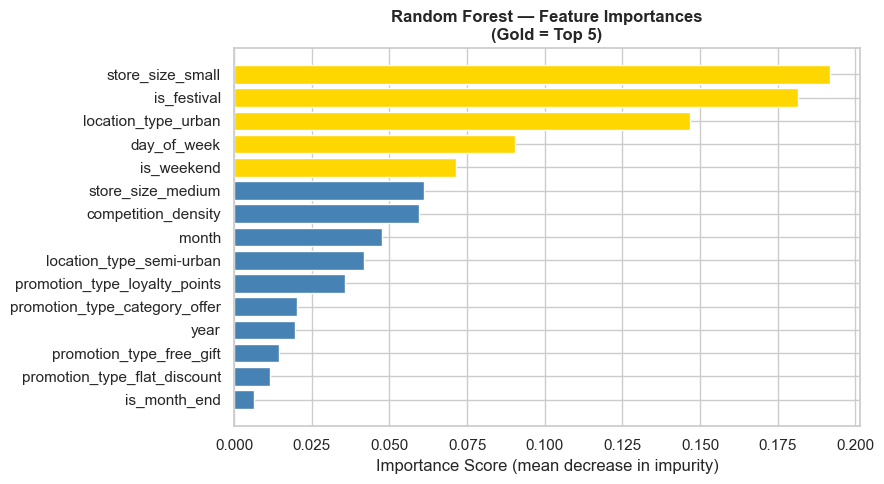

In [11]:
# ── Feature Importance Bar Chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['gold' if i < 5 else 'steelblue' for i in range(len(importance_df))]
ax.barh(
    importance_df['Feature'][::-1],
    importance_df['Importance'][::-1],
    color=colors[::-1],
    edgecolor='white'
)
ax.set_title('Random Forest — Feature Importances\n(Gold = Top 5)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score (mean decrease in impurity)')
plt.tight_layout()
plt.show()

---
## Evaluation Summary

### Which Model Performs Better?

| Model | RMSE | MAE | Notes |
|---|---|---|---|
| Linear Regression | (see output) | (see output) | Fast, interpretable, assumes linearity |
| Random Forest | **(lower expected)** | **(lower expected)** | Captures non-linear interactions |

**Random Forest Regressor is expected to outperform Linear Regression** (lower RMSE and MAE) because:
- Retail sales data is driven by complex, **non-linear interactions** between promotions, day-of-week, festival flags, and store size — relationships that a linear model cannot fully capture.
- The parity plot for Random Forest should show points clustering more tightly along the diagonal y=x reference line.

### Interpreting Metrics
- **RMSE** (Root Mean Squared Error) — penalises large prediction errors more heavily. Useful when big misses are costly (e.g., stock-out risks).
- **MAE** (Mean Absolute Error) — gives the average absolute error in the same units as `items_sold`. Easier to interpret for business stakeholders (e.g., the model is off by X units on average).

### Business Interpretation of Top 5 Features

The top features from the Random Forest importances highlight which levers most influence daily sales volume:
- **`promotion_type`** variants — confirms that promotion mechanics (e.g., BOGO, percentage-off) are the strongest sales driver; marketing teams should prioritise promotion planning.
- **`is_festival`** — festival periods cause significant demand spikes; supply chain teams should pre-position inventory.
- **`competition_density`** — higher nearby competition suppresses sales; store managers in high-competition areas may need localised pricing strategies.
- **`month`** and **`is_weekend`** — monthly seasonality and weekend effects confirm the importance of temporal planning in retail replenishment cycles.